In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns



In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Training data shape:", x_train.shape) 
print("Testing data shape:", x_test.shape)


Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [5]:
# Normalize pixel values 
x_train = x_train / 255.0
x_test = x_test / 255.0
# Reshape for CNN (adding channel dimension)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
# One-hot encode labels
y_train_cat  =  to_categorical(y_train,  10)
y_test_cat  =  to_categorical(y_test,  10)	


In [6]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1))) 
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu')) 
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax')) 
model.summary()


D:\user\envs\tanubhalerao\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile( optimizer='adam',
loss='categorical_crossentropy', metrics=['accuracy']
)


In [8]:
history = model.fit( x_train,  y_train_cat, epochs=10, batch_size=128, validation_split=0.1
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9023 - loss: 0.3226 - val_accuracy: 0.9843 - val_loss: 0.0595
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.9701 - loss: 0.1023 - val_accuracy: 0.9870 - val_loss: 0.0465
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9772 - loss: 0.0770 - val_accuracy: 0.9875 - val_loss: 0.0398
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.9817 - loss: 0.0627 - val_accuracy: 0.9877 - val_loss: 0.0368
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.9831 - loss: 0.0533 - val_accuracy: 0.9902 - val_loss: 0.0355
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9860 - loss: 0.0450 - val_accuracy: 0.9905 - val_loss: 0.0341
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9877 - loss: 0.0412 - val_accuracy: 0.9907 - val_loss: 0.0348
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.9891 - loss: 0.0354 - 

In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9923 - loss: 0.0256
Test Accuracy: 0.9922999739646912


In [11]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


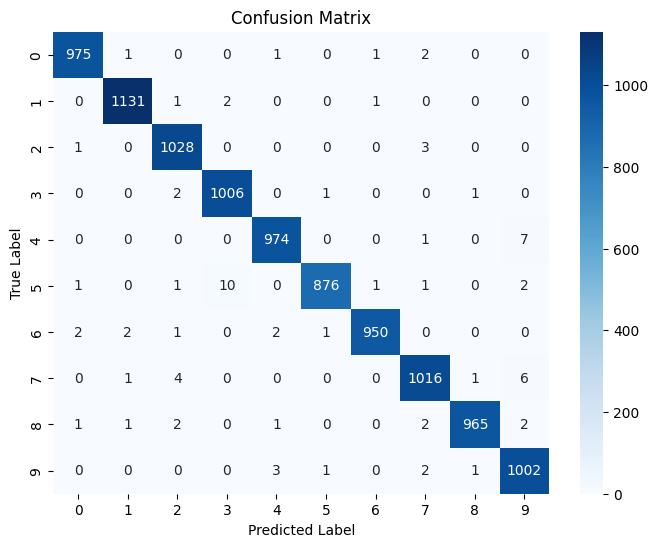

In [12]:
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
